# GRU direta multialvo TUO com CUDA

Este notebook implementa uma GRU que recebe 24 horas históricas da configuração TUO e produz, em uma única passagem, temperatura e umidade de `t+1` a `t+24`.

## Protocolo

- Entradas históricas: TUO + atributos temporais.
- Covariáveis futuras: somente hora e dia do ano codificados ciclicamente.
- Saída: tensor `(24, 2)`.
- Treino: 2011–2023, excluindo 2022.
- Seleção e parada antecipada: 2024.
- Teste fechado: 2025.
- Avaliação adicional: 2026 parcial.
- Treinamento: CUDA quando disponível, com precisão mista automática.
- Inferência e checkpoint final: compatíveis com CPU.
- Comparação: Ridge TUO e HGB TUO completo.

Esta é uma triagem arquitetural com uma semente. Se a GRU for competitiva, a configuração selecionada será repetida posteriormente com as sementes aprovadas no protocolo.

## 1. Importações, reprodutibilidade e dispositivo

In [1]:
from pathlib import Path
import copy
import json
import platform
import random
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch import nn
from torch.utils.data import DataLoader, Dataset

pd.set_option("display.max_columns",100)
pd.set_option("display.width",180)

SEMENTE=42
random.seed(SEMENTE); np.random.seed(SEMENTE); torch.manual_seed(SEMENTE)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEMENTE)

torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
USAR_AMP=DEVICE.type=="cuda"

print("PyTorch:",torch.__version__)
print("Dispositivo:",DEVICE)
if DEVICE.type=="cuda":
 print("GPU:",torch.cuda.get_device_name(0))
 print("VRAM total (GB):",round(torch.cuda.get_device_properties(0).total_memory/1024**3,2))
 print("CUDA runtime:",torch.version.cuda)
else:
 print("ATENÇÃO: CUDA não foi detectada; o notebook usará CPU.")
print("Precisão mista:",USAR_AMP)

PyTorch: 2.14.0+cu126
Dispositivo: cuda
GPU: NVIDIA RTX 500 Ada Generation Laptop GPU
VRAM total (GB): 4.0
CUDA runtime: 12.6
Precisão mista: True


## 2. Caminhos e hiperparâmetros

In [2]:
DIRETORIO_TUO=Path("dados_processados_multivariados/TUO")
DIRETORIO_HGB=Path("resultados_modelagem/hist_gradient_boosting_TUO_48")
DIRETORIO_RIDGE=Path("resultados_modelagem/ablacao_ridge_TU_TUO_TUOV")
DIRETORIO_SAIDA=Path("resultados_modelagem/gru_direta_multialvo_TUO")
DIRETORIO_SAIDA.mkdir(parents=True,exist_ok=True)

SPLITS=["treino","validacao","teste","avaliacao_2026"]
BATCH_SIZE=128
MAX_EPOCAS=60
PACIENCIA=8
LEARNING_RATE=1e-3
WEIGHT_DECAY=1e-5
NUM_WORKERS=0

ARQUITETURAS=[
#  {"nome":"GRU_A","hidden_size":64,"num_layers":1,"dropout":0.0,"decoder_hidden":128},
 {"nome":"GRU_B","hidden_size":96,"num_layers":2,"dropout":0.15,"decoder_hidden":192},
 {"nome":"GRU_C","hidden_size":64,"num_layers":2,"dropout":0.2,"decoder_hidden":128},
]
print("Arquiteturas candidatas:",ARQUITETURAS)

Arquiteturas candidatas: [{'nome': 'GRU_B', 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.15, 'decoder_hidden': 192}, {'nome': 'GRU_C', 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'decoder_hidden': 128}]


## 3. Carregamento dos artefatos TUO

In [3]:
obrigatorios=[DIRETORIO_TUO/f"{s}.npz" for s in SPLITS]+[DIRETORIO_TUO/"scaler_y.joblib",DIRETORIO_TUO/"metadados.json"]
faltantes=[str(x) for x in obrigatorios if not x.exists()]
if faltantes: raise FileNotFoundError("Arquivos ausentes:"+chr(10)+chr(10).join(faltantes))

splits={}
for s in SPLITS:
 with np.load(DIRETORIO_TUO/f"{s}.npz") as arq: splits[s]={k:arq[k] for k in arq.files}
scaler_y=joblib.load(DIRETORIO_TUO/"scaler_y.joblib")
with (DIRETORIO_TUO/"metadados.json").open(encoding="utf-8") as f: meta_preparacao=json.load(f)
assert meta_preparacao["configuracao"]=="TUO"
assert meta_preparacao["usa_covariaveis_meteorologicas_futuras"] is False
for s in SPLITS:
 print(s,splits[s]["X_historico"].shape,splits[s]["X_futuro_temporal"].shape,splits[s]["y"].shape)

treino (84744, 24, 7) (84744, 24, 4) (84744, 24, 2)
validacao (7837, 24, 7) (7837, 24, 4) (7837, 24, 2)
teste (7970, 24, 7) (7970, 24, 4) (7970, 24, 2)
avaliacao_2026 (4551, 24, 7) (4551, 24, 4) (4551, 24, 2)


## 4. Dataset e carregadores

A GRU preserva a forma temporal `(24, 7)` do histórico. Os quatro atributos temporais futuros são fornecidos separadamente ao decodificador. Os alvos permanecem padronizados durante o treinamento para equilibrar temperatura e umidade.

In [4]:
class DatasetMeteorologico(Dataset):
 def __init__(self,split):
  self.xh=torch.from_numpy(split["X_historico"]).float()
  self.xf=torch.from_numpy(split["X_futuro_temporal"]).float()
  self.y=torch.from_numpy(split["y"]).float()
 def __len__(self): return len(self.y)
 def __getitem__(self,i): return self.xh[i],self.xf[i],self.y[i]

datasets={s:DatasetMeteorologico(splits[s]) for s in SPLITS}
g=torch.Generator(); g.manual_seed(SEMENTE)
loaders={
 "treino":DataLoader(datasets["treino"],batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda",generator=g),
 "validacao":DataLoader(datasets["validacao"],batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda"),
 "teste":DataLoader(datasets["teste"],batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda"),
 "avaliacao_2026":DataLoader(datasets["avaliacao_2026"],batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=DEVICE.type=="cuda"),
}
print("Lotes de treino:",len(loaders["treino"]))

Lotes de treino: 663


## 5. Arquitetura

A GRU codifica as 24 horas históricas. O último estado oculto é repetido para os 24 horizontes e concatenado aos atributos temporais futuros. Um decodificador compartilhado produz temperatura e umidade para cada hora futura.

In [5]:
class GRUDiretaMultialvo(nn.Module):
 def __init__(self,n_hist=7,n_fut=4,hidden_size=64,num_layers=1,dropout=0.0,decoder_hidden=128):
  super().__init__()
  self.config=dict(n_hist=n_hist,n_fut=n_fut,hidden_size=hidden_size,num_layers=num_layers,dropout=dropout,decoder_hidden=decoder_hidden)
  self.gru=nn.GRU(input_size=n_hist,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,dropout=dropout if num_layers>1 else 0.0)
  self.decoder=nn.Sequential(nn.Linear(hidden_size+n_fut,decoder_hidden),nn.ReLU(),nn.Dropout(dropout),nn.Linear(decoder_hidden,2))
 def forward(self,x_hist,x_fut):
  _,h=self.gru(x_hist)
  contexto=h[-1].unsqueeze(1).expand(-1,x_fut.size(1),-1)
  return self.decoder(torch.cat([contexto,x_fut],dim=-1))

for cfg in ARQUITETURAS:
 m=GRUDiretaMultialvo(hidden_size=cfg["hidden_size"],num_layers=cfg["num_layers"],dropout=cfg["dropout"],decoder_hidden=cfg["decoder_hidden"])
 print(cfg["nome"],"parâmetros treináveis:",sum(p.numel() for p in m.parameters() if p.requires_grad))

GRU_B parâmetros treináveis: 105890
GRU_C parâmetros treináveis: 48066


## 6. Funções de treinamento e avaliação

In [6]:
LOSS_FN=nn.MSELoss()

def executar_epoca(modelo,loader,otimizador=None,scaler_amp=None):
 treino=otimizador is not None; modelo.train(treino); soma=0.0; n=0
 for xh,xf,yy in loader:
  xh=xh.to(DEVICE,non_blocking=True); xf=xf.to(DEVICE,non_blocking=True); yy=yy.to(DEVICE,non_blocking=True)
  if treino: otimizador.zero_grad(set_to_none=True)
  with torch.autocast(device_type=DEVICE.type,dtype=torch.float16,enabled=USAR_AMP):
   pred=modelo(xh,xf); loss=LOSS_FN(pred,yy)
  if treino:
   scaler_amp.scale(loss).backward(); scaler_amp.unscale_(otimizador)
   torch.nn.utils.clip_grad_norm_(modelo.parameters(),1.0)
   scaler_amp.step(otimizador); scaler_amp.update()
  soma+=loss.item()*len(yy); n+=len(yy)
 return soma/n

@torch.no_grad()
def prever(modelo,loader,device=DEVICE):
 modelo.eval(); saidas=[]; reais=[]
 for xh,xf,yy in loader:
  xh=xh.to(device,non_blocking=True); xf=xf.to(device,non_blocking=True)
  with torch.autocast(device_type=device.type,dtype=torch.float16,enabled=(USAR_AMP and device.type=="cuda")):
   pred=modelo(xh,xf)
  saidas.append(pred.float().cpu().numpy()); reais.append(yy.numpy())
 return np.concatenate(reais),np.concatenate(saidas)

def inverter(y_norm):
 forma=y_norm.shape
 return scaler_y.inverse_transform(y_norm.reshape(-1,2)).reshape(forma)

## 7. Triagem arquitetural com parada antecipada

O progresso por época mostra perdas padronizadas de treino e validação. O melhor estado de cada arquitetura é o de menor perda em 2024.

In [7]:
historicos={}; candidatos={}; resumo=[]
for cfg in ARQUITETURAS:
 print(chr(10)+"="*76); print("TREINANDO",cfg["nome"]); print("="*76)
 modelo=GRUDiretaMultialvo(hidden_size=cfg["hidden_size"],num_layers=cfg["num_layers"],dropout=cfg["dropout"],decoder_hidden=cfg["decoder_hidden"]).to(DEVICE)
 opt=torch.optim.AdamW(modelo.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
 scaler_amp=torch.amp.GradScaler("cuda",enabled=USAR_AMP)
 melhor=np.inf; melhor_estado=None; sem_melhora=0; hist=[]; t0=time.perf_counter()
 if DEVICE.type=="cuda": torch.cuda.reset_peak_memory_stats()
 for epoca in range(1,MAX_EPOCAS+1):
  tr=executar_epoca(modelo,loaders["treino"],opt,scaler_amp)
  va=executar_epoca(modelo,loaders["validacao"])
  hist.append({"arquitetura":cfg["nome"],"epoca":epoca,"loss_treino_padronizada":tr,"loss_validacao_padronizada":va})
  print(f"época {epoca:02d} | treino={tr:.6f} | validação={va:.6f}")
  if va<melhor-1e-6:
   melhor=va; melhor_estado=copy.deepcopy(modelo.state_dict()); sem_melhora=0
  else: sem_melhora+=1
  if sem_melhora>=PACIENCIA:
   print("Parada antecipada."); break
 modelo.load_state_dict(melhor_estado)
 tempo=time.perf_counter()-t0
 pico=(torch.cuda.max_memory_allocated()/1024**3) if DEVICE.type=="cuda" else 0.0
 candidatos[cfg["nome"]]=(modelo,cfg)
 historicos[cfg["nome"]]=pd.DataFrame(hist)
 resumo.append({"arquitetura":cfg["nome"],"melhor_loss_validacao_padronizada":melhor,"epocas_executadas":len(hist),"tempo_segundos":tempo,"pico_vram_gb":pico})
 print(f"Concluído em {tempo/60:.2f} min | melhor validação={melhor:.6f} | pico VRAM={pico:.2f} GB")
resumo_arquiteturas=pd.DataFrame(resumo).sort_values("melhor_loss_validacao_padronizada").reset_index(drop=True)
MELHOR_ARQUITETURA=resumo_arquiteturas.loc[0,"arquitetura"]
print("Arquitetura selecionada em 2024:",MELHOR_ARQUITETURA)
display(resumo_arquiteturas)


TREINANDO GRU_B
época 01 | treino=0.261674 | validação=0.262082
época 02 | treino=0.223703 | validação=0.255336
época 03 | treino=0.217446 | validação=0.248465
época 04 | treino=0.213171 | validação=0.247262
época 05 | treino=0.209009 | validação=0.243458
época 06 | treino=0.203940 | validação=0.246455
época 07 | treino=0.198378 | validação=0.255569
época 08 | treino=0.191389 | validação=0.255756
época 09 | treino=0.183828 | validação=0.261143
época 10 | treino=0.175778 | validação=0.263816
época 11 | treino=0.167678 | validação=0.274133
época 12 | treino=0.160233 | validação=0.268170
época 13 | treino=0.152573 | validação=0.282895
Parada antecipada.
Concluído em 1.80 min | melhor validação=0.243458 | pico VRAM=0.04 GB

TREINANDO GRU_C
época 01 | treino=0.276436 | validação=0.264208
época 02 | treino=0.230454 | validação=0.258434
época 03 | treino=0.224273 | validação=0.249816
época 04 | treino=0.220496 | validação=0.245066
época 05 | treino=0.217056 | validação=0.244052
época 06 | tr

,arquitetura,melhor_loss_validacao_padronizada,epocas_executadas,tempo_segundos,pico_vram_gb
0,GRU_B,0.243458,13,108.157152,0.039223
1,GRU_C,0.244052,13,104.832511,0.031612


## 8. Curvas de treinamento

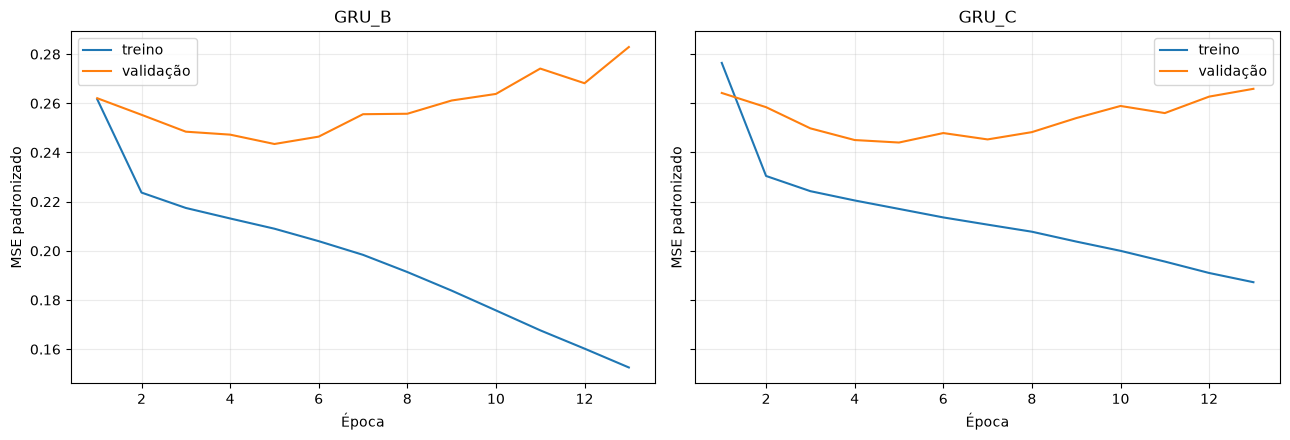

In [8]:
fig,axes=plt.subplots(1,len(ARQUITETURAS),figsize=(13,4.5),sharey=True)
for ax,cfg in zip(axes,ARQUITETURAS):
 h=historicos[cfg["nome"]]
 ax.plot(h.epoca,h.loss_treino_padronizada,label="treino")
 ax.plot(h.epoca,h.loss_validacao_padronizada,label="validação")
 ax.set(title=cfg["nome"],xlabel="Época",ylabel="MSE padronizado"); ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## 9. Avaliação da GRU selecionada e referências

In [9]:
modelo_gru,cfg_gru=candidatos[MELHOR_ARQUITETURA]

# Carrega previsões já geradas pelo HGB e Ridge, evitando nova inferência dos 48 modelos.
previsoes={}
for s in ["validacao","teste","avaliacao_2026"]:
 caminho=DIRETORIO_HGB/f"previsoes_{s}.npz"
 if not caminho.exists(): raise FileNotFoundError(f"Previsões HGB/Ridge não encontradas: {caminho}")
 with np.load(caminho) as arq:
  ref={k:arq[k] for k in arq.files}
 y_norm_real,pred_gru_norm=prever(modelo_gru,loaders[s])
 previsoes[s]={"real":inverter(y_norm_real).astype(np.float32),"gru":inverter(pred_gru_norm).astype(np.float32),
               "hgb":ref["y_pred_hgb"],"ridge":ref["y_pred_ridge"]}
 assert np.allclose(previsoes[s]["real"],ref["y_real"],atol=1e-4)
 print(s,previsoes[s]["gru"].shape)

validacao (7837, 24, 2)
teste (7970, 24, 2)
avaliacao_2026 (4551, 24, 2)


## 10. Métricas Ridge × HGB × GRU

In [10]:
ALVOS={0:("temperatura_c","°C"),1:("umidade_pct","p.p.")}
linhas=[]
for s,d in previsoes.items():
 for nome in ["ridge","hgb","gru"]:
  for h in range(24):
   for j,(alvo,unidade) in ALVOS.items():
    real=d["real"][:,h,j]; pred=d[nome][:,h,j]
    linhas.append({"modelo":nome,"split":s,"horizonte_horas":h+1,"alvo":alvo,"unidade":unidade,
     "mae":mean_absolute_error(real,pred),"rmse":mean_squared_error(real,pred)**0.5,"vies":float(np.mean(pred-real)),"n":len(real)})
metricas_horizonte=pd.DataFrame(linhas)

globais=[]
for s,d in previsoes.items():
 for nome in ["ridge","hgb","gru"]:
  for j,(alvo,unidade) in ALVOS.items():
   real=d["real"][:,:,j].ravel(); pred=d[nome][:,:,j].ravel()
   globais.append({"modelo":nome,"split":s,"alvo":alvo,"unidade":unidade,
    "mae_global_1a24":mean_absolute_error(real,pred),"rmse_global_1a24":mean_squared_error(real,pred)**0.5,
    "vies_global_1a24":float(np.mean(pred-real)),"n_previsoes":len(real)})
metricas_globais=pd.DataFrame(globais)
display(metricas_globais.sort_values(["split","alvo","modelo"]).reset_index(drop=True))

,modelo,split,alvo,unidade,mae_global_1a24,rmse_global_1a24,vies_global_1a24,n_previsoes
0,gru,avaliacao_2026,temperatura_c,°C,1.367272,1.911221,0.021973,109224
1,hgb,avaliacao_2026,temperatura_c,°C,1.386547,1.946017,-0.010110,109224
2,ridge,avaliacao_2026,temperatura_c,°C,1.509436,2.120637,0.047108,109224
3,gru,avaliacao_2026,umidade_pct,p.p.,7.046334,10.024037,-1.709112,109224
4,hgb,avaliacao_2026,umidade_pct,p.p.,7.043255,9.923275,-1.024050,109224
5,ridge,avaliacao_2026,umidade_pct,p.p.,7.308827,10.249426,-1.239488,109224
6,gru,teste,temperatura_c,°C,1.573713,2.240310,-0.058497,191280
7,hgb,teste,temperatura_c,°C,1.576896,2.260600,0.029616,191280
8,ridge,teste,temperatura_c,°C,1.689248,2.395614,0.041565,191280
9,gru,teste,umidade_pct,p.p.,7.943845,11.402447,-0.734061,191280


## 11. Gráficos comparativos

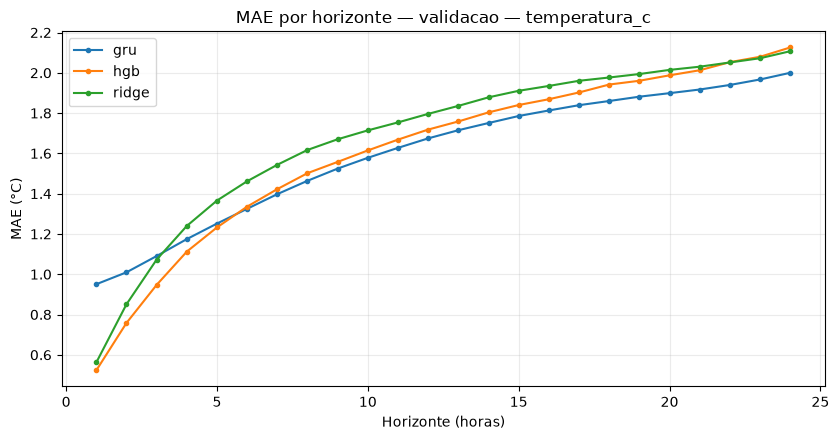

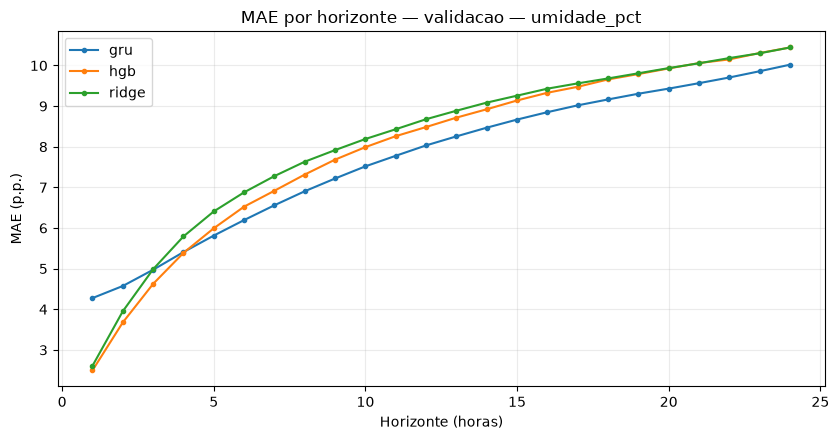

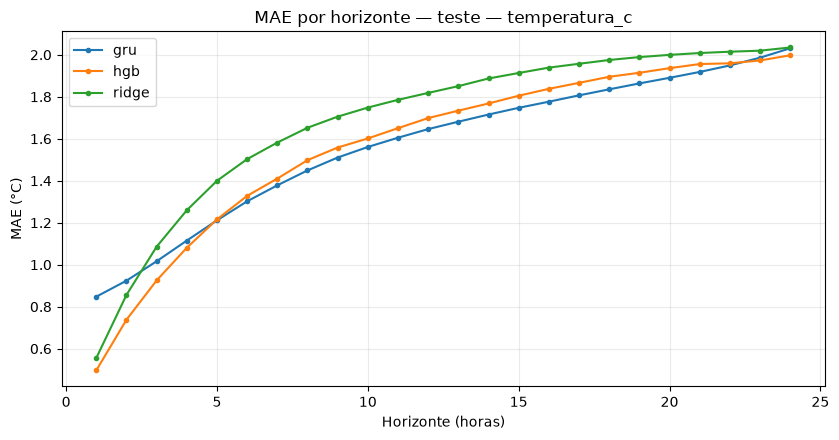

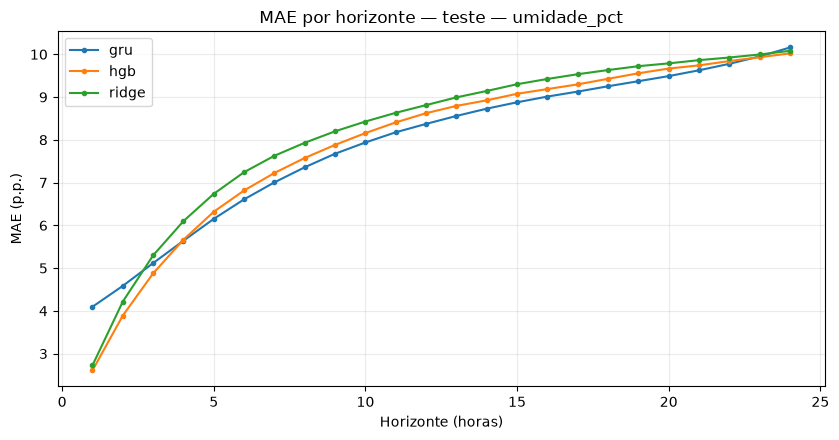

In [11]:
for split in ["validacao","teste"]:
 for alvo in ["temperatura_c","umidade_pct"]:
  d=metricas_horizonte[(metricas_horizonte.split==split)&(metricas_horizonte.alvo==alvo)]
  fig,ax=plt.subplots(figsize=(8.5,4.5))
  for nome,g in d.groupby("modelo"): ax.plot(g.horizonte_horas,g.mae,marker="o",markersize=3,label=nome)
  unidade="°C" if alvo=="temperatura_c" else "p.p."
  ax.set(title=f"MAE por horizonte — {split} — {alvo}",xlabel="Horizonte (horas)",ylabel=f"MAE ({unidade})")
  ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

## 12. Salvamento do checkpoint compatível com CPU

O `state_dict` é transferido para CPU antes de ser salvo. A futura API poderá carregar o modelo sem GPU.

In [12]:
estado_cpu={k:v.detach().cpu() for k,v in modelo_gru.state_dict().items()}
checkpoint={"state_dict":estado_cpu,"model_config":modelo_gru.config,"arquitetura":MELHOR_ARQUITETURA,
 "tau":24,"horizonte":24,"configuracao_atributos":"TUO","colunas_alvo":meta_preparacao["colunas_alvo"],
 "usa_covariaveis_meteorologicas_futuras":False,"inferencia_recomendada":"cpu","scaler_y":scaler_y,
 "metadados_preparacao":meta_preparacao,"semente":SEMENTE}
torch.save(checkpoint,DIRETORIO_SAIDA/"gru_TUO_cpu_checkpoint.pt")
print("Checkpoint salvo:",DIRETORIO_SAIDA/"gru_TUO_cpu_checkpoint.pt")

Checkpoint salvo: resultados_modelagem\gru_direta_multialvo_TUO\gru_TUO_cpu_checkpoint.pt


## 13. Salvamento e verificação final

In [13]:
pd.concat(historicos.values(),ignore_index=True).to_csv(DIRETORIO_SAIDA/"historico_treinamento.csv",index=False,encoding="utf-8-sig")
resumo_arquiteturas.to_csv(DIRETORIO_SAIDA/"selecao_arquitetura_gru_2024.csv",index=False,encoding="utf-8-sig")
metricas_horizonte.to_csv(DIRETORIO_SAIDA/"metricas_por_horizonte_ridge_hgb_gru.csv",index=False,encoding="utf-8-sig")
metricas_globais.to_csv(DIRETORIO_SAIDA/"metricas_globais_ridge_hgb_gru.csv",index=False,encoding="utf-8-sig")
for s,d in previsoes.items(): np.savez_compressed(DIRETORIO_SAIDA/f"previsoes_{s}.npz",**d,inicio_previsao=splits[s]["inicio_previsao"])
meta={"modelo":"GRU direta multialvo","configuracao":"TUO","arquitetura_selecionada":MELHOR_ARQUITETURA,
 "treinamento_dispositivo":str(DEVICE),"amp":USAR_AMP,"inferencia":"CPU","semente":SEMENTE,
 "usa_covariaveis_meteorologicas_futuras":False,"protocolo":"triagem arquitetural de uma semente",
 "versoes":{"python":sys.version.split()[0],"pytorch":torch.__version__,"numpy":np.__version__,"plataforma":platform.platform()}}
with (DIRETORIO_SAIDA/"metadados_gru.json").open("w",encoding="utf-8") as f: json.dump(meta,f,ensure_ascii=False,indent=2)
assert (DIRETORIO_SAIDA/"gru_TUO_cpu_checkpoint.pt").exists()
assert np.isfinite(metricas_globais[["mae_global_1a24","rmse_global_1a24","vies_global_1a24"]].to_numpy()).all()
assert meta["usa_covariaveis_meteorologicas_futuras"] is False
print("VERIFICAÇÃO FINAL: OK")
print("Arquitetura selecionada:",MELHOR_ARQUITETURA)
print("Treinamento:",DEVICE,"| Inferência futura: CPU")

VERIFICAÇÃO FINAL: OK
Arquitetura selecionada: GRU_B
Treinamento: cuda | Inferência futura: CPU


## Encerramento

Envie `selecao_arquitetura_gru_2024.csv`, `metricas_globais_ridge_hgb_gru.csv` e `metricas_por_horizonte_ridge_hgb_gru.csv`. A revisão decidirá se a GRU será repetida com múltiplas sementes ou se HGB será mantido como modelo principal da API.